In [1]:
%pip install -q "transformers>=4.45,<6" "peft>=0.13.0" "accelerate>=0.34.0" "evaluate>=0.4.0" "bitsandbytes>=0.43.0" "underthesea>=9.2.11" "huggingface_hub>=0.25.0" "scikit-learn>=1.5.0" "wandb>=0.18.0" "swanlab[dashboard]>=0.7.11" pandas sentencepiece


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.8/359.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.7/751.7 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.1/161.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.9/411.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.6 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import importlib.util
import json
import re
import sys
import unicodedata
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
from huggingface_hub import hf_hub_download
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from torch.utils.data import Dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    set_seed,
)
from underthesea import word_tokenize

from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")


In [3]:
BASE_MODEL = "vinai/phobert-base"
DATASET_REPO = "dat201204/vietnamese-caucu-comments"
RUN_NAME = "phobert-caucu-v1"
OUTPUT_ROOT = Path("/content/phobert-cau-cuu")
DATA_DIR = OUTPUT_ROOT / "data"
SAVED_MODEL_DIR = OUTPUT_ROOT / "saved_model"

MAX_LENGTH = 256
LEARNING_RATE = 2e-5
BATCH_SIZE = 16
EPOCHS = 5
GRADIENT_ACCUMULATION_STEPS = 1
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SEED = 42
ID2LABEL = {0: "khong_cau_cuu", 1: "cau_cuu"}
LABEL2ID = {label: idx for idx, label in ID2LABEL.items()}

TRACKING_BACKEND = "wandb"  # doi thanh "swanlab" neu ban khong dung W&B
WANDB_PROJECT = "phobert-caucu"
SWANLAB_PROJECT = "phobert-caucu"
TRACKING_TAGS = [RUN_NAME]
SWANLAB_MODE = "local"

DATA_DIR.mkdir(parents=True, exist_ok=True)
SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

REPORT_TO = "none"


In [4]:
def package_available(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


def get_runtime_info() -> dict[str, Any]:
    cuda_available = torch.cuda.is_available()
    info = {
        "cuda_available": cuda_available,
        "cuda_device_count": torch.cuda.device_count() if cuda_available else 0,
        "cuda_name": torch.cuda.get_device_name(0) if cuda_available else None,
        "cuda_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if cuda_available else None,
        "bitsandbytes_available": package_available("bitsandbytes"),
        "unsloth_available": package_available("unsloth"),
    }
    return info


RUNTIME_INFO = get_runtime_info()
RUNTIME_INFO


{'cuda_available': True,
 'cuda_device_count': 1,
 'cuda_name': 'Tesla T4',
 'cuda_memory_gb': 14.56,
 'bitsandbytes_available': True,
 'unsloth_available': False}

In [5]:
def build_tracking_config() -> dict[str, Any]:
    return {
        "base_model": BASE_MODEL,
        "dataset_repo": DATASET_REPO,
        "run_name": RUN_NAME,
        "max_length": MAX_LENGTH,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "seed": SEED,
        "id2label": ID2LABEL,
        "runtime_info": RUNTIME_INFO,
    }


def setup_tracking() -> dict[str, Any]:
    config = build_tracking_config()

    if TRACKING_BACKEND == "wandb":
        try:
            import wandb

            wandb.login()
            run = wandb.init(
                project=WANDB_PROJECT,
                name=RUN_NAME,
                tags=TRACKING_TAGS,
                config=config,
                reinit=True,
            )
            print(f"W&B dashboard URL: {run.url}")
            return {"backend": "wandb", "report_to": "wandb", "run": run}
        except Exception as exc:
            print(f"W&B initialization failed: {exc}")
            print("Falling back to SwanLab local logging.")

    try:
        import swanlab

        swanlog_dir = OUTPUT_ROOT / "swanlog"
        swanlog_dir.mkdir(parents=True, exist_ok=True)
        run = swanlab.init(
            project=SWANLAB_PROJECT,
            experiment_name=RUN_NAME,
            tags=TRACKING_TAGS,
            config=config,
            mode=SWANLAB_MODE,
            logdir=str(swanlog_dir),
        )
        print(f"SwanLab local logdir: {swanlog_dir}")
        return {"backend": "swanlab", "report_to": "none", "run": run}
    except Exception as exc:
        print(f"SwanLab initialization failed: {exc}")
        print("Training will continue without external tracking.")
        return {"backend": "none", "report_to": "none", "run": None}


def finish_tracking() -> None:
    if TRACKING_STATE["backend"] == "wandb":
        import wandb

        wandb.finish()
    elif TRACKING_STATE["backend"] == "swanlab" and TRACKING_STATE["run"] is not None:
        TRACKING_STATE["run"].finish()


TRACKING_STATE = setup_tracking()
REPORT_TO = TRACKING_STATE["report_to"]
TRACKING_STATE


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 Don't visualize my results


wandb: WARNING Invalid choice
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING URL not available in offline run


W&B dashboard URL: None


{'backend': 'wandb',
 'report_to': 'wandb',
 'run': <wandb.sdk.wandb_run.Run at 0x7c58ed5b72c0>}

In [6]:
ZERO_WIDTH_PATTERN = re.compile(r"[\u200b\u200c\u200d\ufeff]")
WHITESPACE_PATTERN = re.compile(r"\s+")


def normalize_text(text: str) -> str:
    normalized = unicodedata.normalize("NFC", text or "")
    normalized = ZERO_WIDTH_PATTERN.sub(" ", normalized)
    normalized = WHITESPACE_PATTERN.sub(" ", normalized).strip()
    return normalized


def segment_text(text: str) -> str:
    if not text:
        return ""
    segmented = word_tokenize(text, format="text")
    return WHITESPACE_PATTERN.sub(" ", segmented).strip()


def prepare_dataframe(input_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(input_csv, encoding="utf-8-sig")
    df["text"] = df["text"].fillna("").astype(str)
    df["label"] = df["label"].astype(int)
    df["confidence"] = df["confidence"].astype(float)

    df["normalized_text"] = df["text"].map(normalize_text)
    df = df[df["normalized_text"].str.len() > 0].copy()
    df["segmented_text"] = df["normalized_text"].map(segment_text)
    df["model_input_text"] = df["segmented_text"].where(df["segmented_text"].str.len() > 0, df["normalized_text"])
    return df.reset_index(drop=True)


def stratified_split(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=seed,
        stratify=df["label"],
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=seed,
        stratify=temp_df["label"],
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def compute_class_weights_dict(labels: pd.Series) -> dict[str, float]:
    classes = np.array(sorted(labels.unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=labels)
    return {str(int(label)): float(weight) for label, weight in zip(classes, weights)}


def save_split(df: pd.DataFrame, output_path: Path) -> None:
    columns = ["id", "text", "normalized_text", "segmented_text", "model_input_text", "label", "confidence"]
    df.to_csv(output_path, index=False, encoding="utf-8-sig", columns=columns)


In [7]:
labeled_csv_path = Path(
    hf_hub_download(
        repo_id=DATASET_REPO,
        repo_type="dataset",
        filename="labeled_comments.csv",
    )
)

full_df = prepare_dataframe(labeled_csv_path)
train_df, val_df, test_df = stratified_split(full_df, SEED)
class_weights = compute_class_weights_dict(full_df["label"])

save_split(train_df, DATA_DIR / "train.csv")
save_split(val_df, DATA_DIR / "val.csv")
save_split(test_df, DATA_DIR / "test.csv")
(DATA_DIR / "class_weights.json").write_text(json.dumps(class_weights, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Total cleaned rows: {len(full_df)}")
print(f"Class weights: {class_weights}")
print("train distribution:", train_df["label"].value_counts().sort_index().to_dict())
print("val distribution:", val_df["label"].value_counts().sort_index().to_dict())
print("test distribution:", test_df["label"].value_counts().sort_index().to_dict())
train_df.head(3)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


labeled_comments.csv: 0.00B [00:00, ?B/s]

Total cleaned rows: 1304
Class weights: {'0': 0.7563805104408353, '1': 1.4751131221719458}
train distribution: {0: 603, 1: 309}
val distribution: {0: 129, 1: 67}
test distribution: {0: 130, 1: 66}


,id,text,label,confidence,normalized_text,segmented_text,model_input_text
0,10239674864474861-top-0296,Quyetloi Bui bên nhà cô bị khu vực nào Phú Yên...,0,0.60,Quyetloi Bui bên nhà cô bị khu vực nào Phú Yên...,Quyetloi Bui bên nhà cô bị khu_vực nào Phú_Yên...,Quyetloi Bui bên nhà cô bị khu_vực nào Phú_Yên...
1,10239674864474861-top-1080,Một năm đầy thiên tai bão quanh cả nước . khổ,0,0.60,Một năm đầy thiên tai bão quanh cả nước . khổ,Một năm đầy thiên_tai_bão quanh cả nước . khổ,Một năm đầy thiên_tai_bão quanh cả nước . khổ
2,10239674864474861-top-1051,"SOS: gia đình có 8 người, có người già và trẻ ...",1,0.93,"SOS: gia đình có 8 người, có người già và trẻ ...","SOS : gia_đình có 8 người , có người già và tr...","SOS : gia_đình có 8 người , có người già và tr..."


In [8]:
class EncodedCommentDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer: Any, max_length: int) -> None:
        texts = frame["model_input_text"].fillna("").astype(str).tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.ids = frame["id"].astype(str).tolist()
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        item = {key: torch.tensor(value[index], dtype=torch.long) for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index], dtype=torch.long)
        return item


class WeightedClassificationTrainer(Trainer):
    def __init__(self, *args: Any, class_weights: torch.Tensor, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        model_inputs = dict(inputs)
        labels = model_inputs.pop("labels")
        outputs = model(**model_inputs)
        logits = outputs.logits
        weights = self.class_weights.to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss


class EpochMetricsLoggerCallback(TrainerCallback):
    def __init__(self, backend: str) -> None:
        self.backend = backend

    def _emit(self, payload: dict[str, Any], step: int | None) -> None:
        filtered = {key: value for key, value in payload.items() if value is not None}
        if not filtered:
            return

        if self.backend == "wandb":
            import wandb

            wandb.log(filtered, step=step)
        elif self.backend == "swanlab":
            import swanlab

            swanlab.log(filtered, step=step)

    def on_log(self, args, state, control, logs=None, **kwargs):
        logs = logs or {}
        if "loss" not in logs:
            return
        epoch = float(state.epoch) if state.epoch is not None else None
        step = int(state.global_step) if state.global_step is not None else None
        self._emit({"train_loss": float(logs["loss"]), "epoch": epoch}, step=step)

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        metrics = metrics or {}
        epoch = float(state.epoch) if state.epoch is not None else None
        step = int(state.global_step) if state.global_step is not None else None
        self._emit(
            {
                "val_loss": metrics.get("eval_loss"),
                "val_f1_cau_cuu": metrics.get("eval_f1_cau_cuu"),
                "val_recall_cau_cuu": metrics.get("eval_recall_cau_cuu"),
                "epoch": epoch,
            },
            step=step,
        )


def compute_metrics(eval_prediction):
    predictions = eval_prediction.predictions
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    preds = np.argmax(predictions, axis=-1)
    labels = eval_prediction.label_ids
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_cau_cuu": float(f1_score(labels, preds, average="binary", pos_label=1, zero_division=0)),
        "recall_cau_cuu": float(recall_score(labels, preds, average="binary", pos_label=1, zero_division=0)),
    }


def infer_lora_target_modules(model: torch.nn.Module) -> list[str]:
    discovered = set()
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            suffix = name.split(".")[-1]
            if suffix in {"query", "value"}:
                discovered.add(suffix)
    return sorted(discovered) or ["query", "value"]


def infer_modules_to_save(model: torch.nn.Module) -> list[str] | None:
    modules = [candidate for candidate in ("classifier", "score", "pre_classifier") if hasattr(model, candidate)]
    return modules or None


def resolve_precision_flags() -> tuple[bool, bool]:
    if not torch.cuda.is_available():
        return False, False
    supports_bf16 = bool(getattr(torch.cuda, "is_bf16_supported", lambda: False)())
    return supports_bf16, not supports_bf16


def build_model_and_tokenizer() -> tuple[torch.nn.Module, Any, dict[str, Any]]:
    config = AutoConfig.from_pretrained(BASE_MODEL)
    config.num_labels = 2
    config.id2label = ID2LABEL
    config.label2id = LABEL2ID
    config.problem_type = "single_label_classification"

    quantization_config = None
    quantization_mode = "disabled"
    if torch.cuda.is_available() and package_available("bitsandbytes") and (RUNTIME_INFO["cuda_memory_gb"] or 0) < 8:
        quantization_config = BitsAndBytesConfig(load_in_8bit=True)
        quantization_mode = "8bit"

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=False)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token or tokenizer.sep_token or tokenizer.unk_token

    model_kwargs = {"config": config}
    if quantization_config is not None:
        model_kwargs["quantization_config"] = quantization_config
        model_kwargs["device_map"] = "auto"

    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, **model_kwargs)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False

    if quantization_config is not None:
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
    elif torch.cuda.is_available() and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
        if hasattr(model, "enable_input_require_grads"):
            model.enable_input_require_grads()

    target_modules = infer_lora_target_modules(model)
    modules_to_save = infer_modules_to_save(model)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=target_modules,
        modules_to_save=modules_to_save,
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    unsloth_status = {
        "available": package_available("unsloth"),
        "enabled": False,
        "reason": "PhoBERT is an encoder-based sequence classifier, so Unsloth is intentionally skipped.",
    }

    runtime = {
        **RUNTIME_INFO,
        "quantization_mode": quantization_mode,
        "lora_target_modules": target_modules,
        "modules_to_save": modules_to_save or [],
        "unsloth": unsloth_status,
    }
    return model, tokenizer, runtime


In [9]:
set_seed(SEED)

model, tokenizer, runtime = build_model_and_tokenizer()
class_weight_tensor = torch.tensor([class_weights["0"], class_weights["1"]], dtype=torch.float)

train_dataset = EncodedCommentDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = EncodedCommentDataset(val_df, tokenizer, MAX_LENGTH)

bf16, fp16 = resolve_precision_flags()
optim_name = "paged_adamw_8bit" if runtime["quantization_mode"] == "8bit" else "adamw_torch"

print(runtime)
print({"tracking_backend": TRACKING_STATE["backend"], "report_to": REPORT_TO})


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

trainable params: 1,181,954 || all params: 136,181,764 || trainable%: 0.8679
{'cuda_available': True, 'cuda_device_count': 1, 'cuda_name': 'Tesla T4', 'cuda_memory_gb': 14.56, 'bitsandbytes_available': True, 'unsloth_available': False, 'quantization_mode': 'disabled', 'lora_target_modules': ['query', 'value'], 'modules_to_save': ['classifier', 'classifier', 'score'], 'unsloth': {'available': False, 'enabled': False, 'reason': 'PhoBERT is an encoder-based sequence classifier, so Unsloth is intentionally skipped.'}}
{'tracking_backend': 'wandb', 'report_to': 'wandb'}


In [10]:
training_args = TrainingArguments(
    output_dir=str(SAVED_MODEL_DIR),
    do_train=True,
    do_eval=True,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    optim=optim_name,
    bf16=bf16,
    fp16=fp16,
    gradient_checkpointing=torch.cuda.is_available(),
    use_cpu=not torch.cuda.is_available(),
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_recall_cau_cuu",
    greater_is_better=True,
    report_to=REPORT_TO,
    run_name=RUN_NAME,
    remove_unused_columns=False,
    label_names=["labels"],
    dataloader_pin_memory=torch.cuda.is_available(),
    seed=SEED,
)

trainer = WeightedClassificationTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(
        tokenizer=tokenizer,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    ),
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        EpochMetricsLoggerCallback(TRACKING_STATE["backend"]),
    ],
    class_weights=class_weight_tensor,
)

trainer


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [11]:
train_result = trainer.train()
trainer.save_model(str(SAVED_MODEL_DIR))
tokenizer.save_pretrained(str(SAVED_MODEL_DIR))
trainer.save_state()

train_metrics = dict(train_result.metrics)
eval_metrics = trainer.evaluate()

summary = {
    "best_model_checkpoint": trainer.state.best_model_checkpoint,
    "best_metric": trainer.state.best_metric,
    "train_metrics": train_metrics,
    "eval_metrics": eval_metrics,
    "runtime": runtime,
    "class_weights": class_weights,
    "tracking_backend": TRACKING_STATE["backend"],
}

(SAVED_MODEL_DIR / "training_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

if TRACKING_STATE["backend"] == "wandb" and TRACKING_STATE["run"] is not None:
    TRACKING_STATE["run"].summary.update(
        {
            "best_model_checkpoint": trainer.state.best_model_checkpoint,
            "best_metric": trainer.state.best_metric,
            "eval_recall_cau_cuu": eval_metrics.get("eval_recall_cau_cuu"),
            "eval_f1_cau_cuu": eval_metrics.get("eval_f1_cau_cuu"),
            "eval_loss": eval_metrics.get("eval_loss"),
        }
    )

finish_tracking()
summary


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Cau Cuu,Recall Cau Cuu
1,0.635946,0.558420,0.806122,0.800813,0.768293,0.940299
2,0.523362,0.457993,0.836735,0.827218,0.786667,0.880597
3,0.434442,0.405349,0.841837,0.831293,0.789116,0.865672


epoch,▁▅█
eval/accuracy,▁▇█▁
eval/f1_cau_cuu,▁▇█▁
eval/f1_macro,▁▇█▁
eval/loss,█▃▁█
eval/recall_cau_cuu,█▂▁█
eval/runtime,▆█▂▁
eval/samples_per_second,▃▁▇█
eval/steps_per_second,▃▁▇█
train/epoch,▁▁▅▅████
+5,...


{'best_model_checkpoint': '/content/phobert-cau-cuu/saved_model/checkpoint-57',
 'best_metric': 0.9402985074626866,
 'train_metrics': {'train_runtime': 111.4058,
  'train_samples_per_second': 40.931,
  'train_steps_per_second': 2.558,
  'total_flos': 189786945841152.0,
  'train_loss': 0.5312497880723741,
  'epoch': 3.0},
 'eval_metrics': {'eval_loss': 0.5584200620651245,
  'eval_accuracy': 0.8061224489795918,
  'eval_f1_macro': 0.8008130081300813,
  'eval_f1_cau_cuu': 0.7682926829268293,
  'eval_recall_cau_cuu': 0.9402985074626866,
  'eval_runtime': 2.1268,
  'eval_samples_per_second': 92.156,
  'eval_steps_per_second': 6.112,
  'epoch': 3.0},
 'runtime': {'cuda_available': True,
  'cuda_device_count': 1,
  'cuda_name': 'Tesla T4',
  'cuda_memory_gb': 14.56,
  'bitsandbytes_available': True,
  'unsloth_available': False,
  'quantization_mode': 'disabled',
  'lora_target_modules': ['query', 'value'],
  'modules_to_save': ['classifier', 'classifier', 'score'],
  'unsloth': {'available': 

In [12]:
!python /content/evaluate.py \
  --model-dir /content/phobert-cau-cuu/saved_model \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --test-csv /content/phobert-cau-cuu/data/test.csv \
  --output-dir /content/phobert-cau-cuu/results \
  --device cuda

Loading weights: 100% 197/197 [00:00<00:00, 948.04it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight] 
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

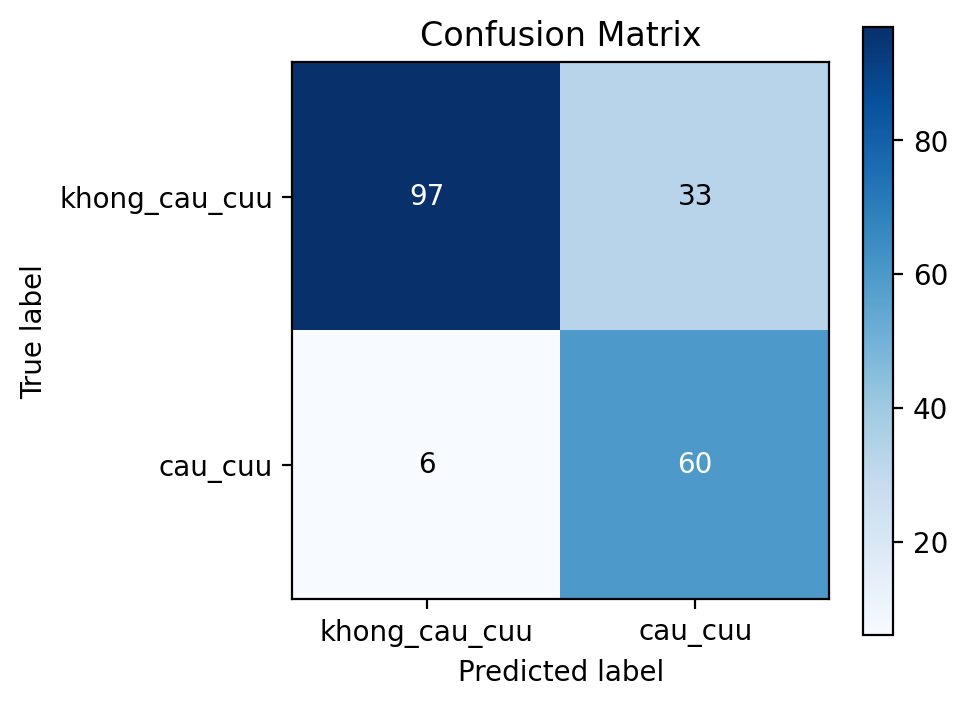

In [13]:
from IPython.display import Image, display
display(Image('/content/phobert-cau-cuu/results/confusion_matrix.png'))

In [14]:
!python /content/evaluate.py \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --test-csv /content/phobert-cau-cuu/data/test.csv \
  --output-dir /content/phobert-cau-cuu/results_ckpt171 \
  --device cuda

Loading weights: 100% 197/197 [00:00<00:00, 1372.05it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [15]:
!python /content/evaluate.py \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --test-csv /content/phobert-cau-cuu/data/test.csv \
  --output-dir /content/phobert-cau-cuu/results_ckpt171_r088 \
  --device cuda \
  --target-recall 0.88


Loading weights: 100% 197/197 [00:00<00:00, 1102.18it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [16]:
!python /content/evaluate.py \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --test-csv /content/phobert-cau-cuu/data/test.csv \
  --output-dir /content/phobert-cau-cuu/results_ckpt171_r090 \
  --device cuda \
  --target-recall 0.90


Loading weights: 100% 197/197 [00:00<00:00, 1008.79it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [17]:
!python /content/evaluate.py \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --test-csv /content/phobert-cau-cuu/data/test.csv \
  --output-dir /content/phobert-cau-cuu/results_final \
  --device cuda \
  --target-recall 0.88


Loading weights: 100% 197/197 [00:00<00:00, 896.60it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight] 
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [18]:
from getpass import getpass
import os
os.environ["HF_TOKEN"] = getpass("HF_TOKEN: ")

HF_TOKEN: ··········


In [19]:
%pip install -q "huggingface_hub>=0.25.0"
!hf auth whoami

A new version of huggingface_hub (1.8.0) is available! You are using version 1.7.1.
To update, run: pip install -U huggingface_hub

user:  dat201204


In [20]:
!python /content/push_model_to_hf.py \
  --source-model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --evaluation-summary /content/phobert-cau-cuu/results_final/evaluation_summary.json \
  --export-dir /content/phobert-cau-cuu/model_release \
  --repo-id dat201204/phobert-vi-caucu-classifier \
  --public

Prepared release folder: /content/phobert-cau-cuu/model_release
Copied files (7): ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'added_tokens.json', 'bpe.codes', 'tokenizer_config.json', 'vocab.txt']
Model card written: /content/phobert-cau-cuu/model_release/README.md

Run these commands on Colab to push to Hugging Face Hub:
hf repos create dat201204/phobert-vi-caucu-classifier --type model --exist-ok --public
hf upload-large-folder dat201204/phobert-vi-caucu-classifier /content/phobert-cau-cuu/model_release --type model


In [21]:
!hf repos create dat201204/phobert-vi-caucu-classifier --type model --exist-ok --public
!hf upload-large-folder dat201204/phobert-vi-caucu-classifier /content/phobert-cau-cuu/model_release --type model

Usage: hf repos create [OPTIONS] REPO_ID
Try 'hf repos create -h' for help.

Error: No such option: --public
You are about to upload a large folder to the Hub using `hf upload-large-folder`. This is a new feature so feedback is very welcome!

A few things to keep in mind:
  - Repository limits still apply: https://huggingface.co/docs/hub/repositories-recommendations
  - Do not start several processes in parallel.
  - You can interrupt and resume the process at any time. The script will pick up where it left off except for partially uploaded files that would have to be entirely reuploaded.
  - Do not upload the same folder to several repositories. If you need to do so, you must delete the `./.cache/huggingface/` folder first.

Some temporary metadata will be stored under `/content/phobert-cau-cuu/model_release/.cache/huggingface`.
  - You must not modify those files manually.
  - You must not delete the `./.cache/huggingface/` folder while a process is running.
  - You can delete the `.

In [25]:
!python /content/predict.py \
  --model-source /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --summary-json /content/phobert-cau-cuu/results_final/evaluation_summary.json \
  --device cuda \
  --demo

Loading weights: 100% 197/197 [00:00<00:00, 1224.13it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [26]:
!python /content/predict.py \
  --model-source /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --summary-json /content/phobert-cau-cuu/results_final/evaluation_summary.json \
  --device cuda \
  --text "Cứu với, nhà em đang ngập sâu và có người già bị kẹt"

Loading weights: 100% 197/197 [00:00<00:00, 1398.30it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [32]:
!python /content/phobert-cau-cuu/threshold_optimizer.py \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --val-csv /content/phobert-cau-cuu/data/val.csv \
  --results-dir /content/phobert-cau-cuu/results \
  --config-json /content/phobert-cau-cuu/config.json \
  --device cuda

Loading weights: 100% 197/197 [00:00<00:00, 1075.35it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [33]:
!python /content/phobert-cau-cuu/filter_pipeline.py \
  --json-file /content/10239674864474861.json \
  --output-file /content/phobert-cau-cuu/results/filtered_comments.json \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --config-json /content/phobert-cau-cuu/config.json \
  --device cuda

Loading weights: 100% 197/197 [00:00<00:00, 1043.81it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

In [34]:
!python /content/phobert-cau-cuu/dedup.py \
  --input-file /content/phobert-cau-cuu/results/filtered_comments.json \
  --output-file /content/phobert-cau-cuu/results/filtered_deduped_comments.json

Trước: 655 comments -> Sau: 632 comments (loại 23 duplicates)
{
  "before_count": 655,
  "after_count": 632,
  "duplicates_removed": 23,
  "exact_duplicates_removed": 8,
  "near_duplicates_removed": 15,
  "output_file": "/content/phobert-cau-cuu/results/filtered_deduped_comments.json",
  "similarity_threshold": 0.85
}


In [35]:
!python /content/phobert-cau-cuu/quality_report.py \
  --input-file /content/phobert-cau-cuu/results/filtered_deduped_comments.json \
  --output-file /content/phobert-cau-cuu/results/filter_quality_report.html \
  --raw-json-file /content/10239674864474861.json \
  --filtered-file /content/phobert-cau-cuu/results/filtered_comments.json

{
  "raw_total_comments": 1492,
  "filtered_comments": 655,
  "deduped_comments": 632,
  "duplicates_removed": 23,
  "phone_count": 355,
  "gps_count": 23,
  "address_count": 413,
  "output_file": "/content/phobert-cau-cuu/results/filter_quality_report.html"
}


In [36]:
!python /content/phobert-cau-cuu/run_pipeline.py \
  --json-file /content/10239674864474861.json \
  --model-dir /content/phobert-cau-cuu/saved_model/checkpoint-171 \
  --config-json /content/phobert-cau-cuu/config.json \
  --device cuda

Loading weights: 100% 197/197 [00:00<00:00, 907.64it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored whe

In [39]:
from getpass import getpass
import os
os.environ["HF_TOKEN"] = getpass("HF_TOKEN: ")


HF_TOKEN: ··········


In [40]:
!pip -q install -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 12.7 MB/s eta 0:00:00


In [41]:
!mkdir -p /content/space_app
!cp /content/app.py /content/app_caucu.py /content/upload_json_filter.py /content/requirements.txt /content/README.md /content/space_app/
!ls /content/space_app

app_caucu.py  app.py  README.md  requirements.txt  upload_json_filter.py


In [42]:
from huggingface_hub import HfApi, create_repo
import os

repo_id = "dat201204/phobert-vi-caucu-demo"

create_repo(
    repo_id=repo_id,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True,
    private=False,
    token=os.environ["HF_TOKEN"],
)

api = HfApi(token=os.environ["HF_TOKEN"])
api.upload_folder(
    repo_id=repo_id,
    repo_type="space",
    folder_path="/content/space_app",
    commit_message="Update Gradio app with JSON filter tab",
    ignore_patterns=["__pycache__/*", "*.pyc", ".cache/*"],
)

print(f"https://huggingface.co/spaces/{repo_id}")

No files have been modified since last commit. Skipping to prevent empty commit.


https://huggingface.co/spaces/dat201204/phobert-vi-caucu-demo


In [43]:
!ls /content/space_app
!grep -n "Upload JSON File Filter" /content/space_app/app_caucu.py
!grep -n "upload_json_filter" /content/space_app/app_caucu.py

app_caucu.py  app.py  README.md  requirements.txt  upload_json_filter.py
682:    with gr.Tab("Upload JSON File Filter"):
18:from upload_json_filter import filter_uploaded_json_with_predictor
